In [2]:
from google.colab import files
uploaded = files.upload()

Saving clean_customer_churn.csv to clean_customer_churn.csv


In [3]:
import pandas as pd
df = pd.read_csv("clean_customer_churn.csv")
df.head()

,customer_id,age,gender,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_support_tickets,signup_date,has_churned,tenure_years,avg_monthly_spend,tickets_per_month,tenure_category
0,CUST00121,43.0,Female,70.0,Month-to-month,Credit card,59.74,4178.01,0.0,2019-09-17,No,5.833333,58.845211,0.000000,Loyal
1,CUST00178,27.0,Female,47.0,Two year,Bank transfer,112.67,5319.53,2.0,2022-03-13,Yes,3.916667,110.823542,0.041667,Loyal
2,CUST00222,43.0,Female,0.0,One year,Credit card,69.50,0.00,1.0,2021-11-24,Yes,0.000000,0.000000,1.000000,New
3,CUST00378,60.0,Male,44.0,One year,Electronic check,87.66,3832.18,3.0,2022-10-25,Yes,3.666667,85.159556,0.066667,Loyal
4,CUST00279,21.0,Female,50.0,Month-to-month,Electronic check,54.93,2125.99,1.0,2022-05-24,No,4.166667,41.686078,0.019608,Loyal


Dataset Inspection

In [5]:
X = df.drop(columns=["customer_id", "signup_date", "has_churned"])
y = df["has_churned"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Features shape: (420, 12)
Target shape: (420,)

Target Distribution:
has_churned
No     302
Yes    118
Name: count, dtype: int64


In [4]:
print(df.shape)
print(df.columns)
df.info()
df.isnull().sum()

(420, 15)
Index(['customer_id', 'age', 'gender', 'tenure_months', 'contract_type',
       'payment_method', 'monthly_charges', 'total_charges',
       'num_support_tickets', 'signup_date', 'has_churned', 'tenure_years',
       'avg_monthly_spend', 'tickets_per_month', 'tenure_category'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          420 non-null    object 
 1   age                  420 non-null    float64
 2   gender               420 non-null    object 
 3   tenure_months        420 non-null    float64
 4   contract_type        420 non-null    object 
 5   payment_method       420 non-null    object 
 6   monthly_charges      420 non-null    float64
 7   total_charges        420 non-null    float64
 8   num_support_tickets  420 non-null    float64
 9   signup_date          420 non-

,0
customer_id,0
age,0
gender,0
tenure_months,0
contract_type,0
payment_method,0
monthly_charges,0
total_charges,0
num_support_tickets,0
signup_date,0


Select Features and Split the Dataset

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (336, 12)
Testing set: (84, 12)


Identify Numerical and Categorical Columns

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['gender', 'contract_type', 'payment_method', 'tenure_category']
Numerical Features: ['age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_tickets', 'tenure_years', 'avg_monthly_spend', 'tickets_per_month']


Create the Preprocessing Pipeline

In [9]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


Import Required Libraries

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

Create and Train Logistic Regression

In [12]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=1000))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Create and Train Random Forest

In [13]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Import required Libraries

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

Make Predictions

In [14]:
# Logistic Regression Predictions
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

# Random Forest Predictions
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation Accuracy for Logistic Regression")
print("Scores:", cv_scores)
print("Average Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross-validation Accuracy for Logistic Regression
Scores: [0.71428571 0.79761905 0.69047619 0.72619048 0.80952381]
Average Accuracy: 0.7476190476190476
Standard Deviation: 0.04726055533637909


Evaluate both the models

In [18]:
# Logistic Regression Metrics
lr_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr, pos_label="Yes"),
    "Recall": recall_score(y_test, y_pred_lr, pos_label="Yes"),
    "F1 Score": f1_score(y_test, y_pred_lr, pos_label="Yes"),
    "ROC-AUC": roc_auc_score((y_test == "Yes").astype(int), y_prob_lr)
}

# Random Forest Metrics
rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, pos_label="Yes"),
    "Recall": recall_score(y_test, y_pred_rf, pos_label="Yes"),
    "F1 Score": f1_score(y_test, y_pred_rf, pos_label="Yes"),
    "ROC-AUC": roc_auc_score((y_test == "Yes").astype(int), y_prob_rf)
}

# Comparison Table
comparison = pd.DataFrame([lr_metrics, rf_metrics],
                          index=["Logistic Regression", "Random Forest"])

comparison

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.761905,0.611111,0.458333,0.523810,0.769444
Random Forest,0.750000,0.588235,0.416667,0.487805,0.679167


In [19]:
from sklearn.metrics import accuracy_score

train_pred_lr = logistic_model.predict(X_train)
test_pred_lr = logistic_model.predict(X_test)

train_accuracy_lr = accuracy_score(y_train, train_pred_lr)
test_accuracy_lr = accuracy_score(y_test, test_pred_lr)

print("Logistic Regression Train Accuracy:", train_accuracy_lr)
print("Logistic Regression Test Accuracy :", test_accuracy_lr)

Logistic Regression Train Accuracy: 0.7619047619047619
Logistic Regression Test Accuracy : 0.7619047619047619


In [20]:
train_pred_rf = random_forest_model.predict(X_train)
test_pred_rf = random_forest_model.predict(X_test)

train_accuracy_rf = accuracy_score(y_train, train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, test_pred_rf)

print("Random Forest Train Accuracy:", train_accuracy_rf)
print("Random Forest Test Accuracy :", test_accuracy_rf)

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy : 0.75


Feature Analysis

Convert Target to Numeric (for Correlation)

In [21]:
corr_df = df.copy()
corr_df["has_churned"] = corr_df["has_churned"].map({"No": 0, "Yes": 1})

Correlation with target

has_churned            1.000000
tickets_per_month      0.171767
avg_monthly_spend      0.134662
monthly_charges        0.097388
age                    0.069392
num_support_tickets    0.031771
total_charges         -0.181329
tenure_years          -0.296967
tenure_months         -0.296967
Name: has_churned, dtype: float64


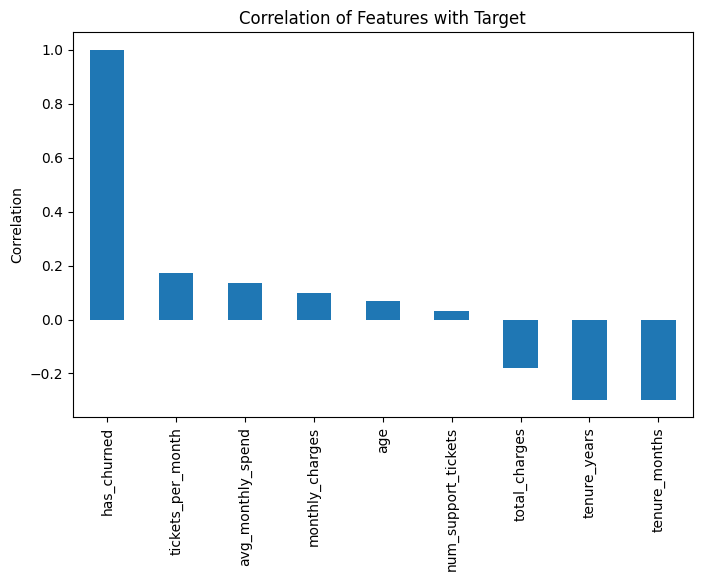

In [22]:
import matplotlib.pyplot as plt

# Correlation with target
target_corr = corr_df.corr(numeric_only=True)["has_churned"].sort_values(ascending=False)

print(target_corr)

# Plot
plt.figure(figsize=(8,5))
target_corr.plot(kind="bar")
plt.title("Correlation of Features with Target")
plt.ylabel("Correlation")
plt.show()

Correlation Between Numerical Features

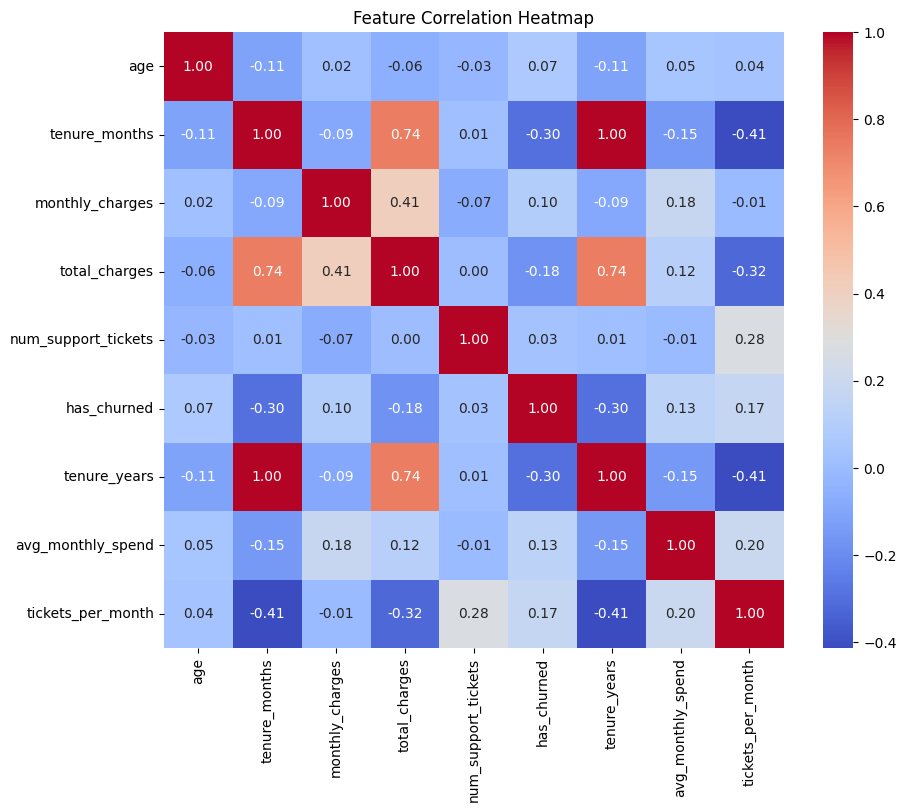

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [27]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tenure_months',
                                                   'monthly_charges',
                                                   'total_charges',
                                                   'num_support_tickets',
                                                   'tenure_years',
                                                   'avg_monthly_spend',
                                                   'tickets_per_month']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'contract_type',
                                                   'payment_method',
                                                   'tenure_category'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=5,
                                        min_samples_split=10,
                                        random_state=42))])

In [28]:
train_pred_rf = random_forest_model.predict(X_train)
test_pred_rf = random_forest_model.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, test_pred_rf))

Train Accuracy: 0.8452380952380952
Test Accuracy: 0.7738095238095238


In [29]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tenure_months',
                                                   'monthly_charges',
                                                   'total_charges',
                                                   'num_support_tickets',
                                                   'tenure_years',
                                                   'avg_monthly_spend',
                                                   'tickets_per_month']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'contract_type',
                                                   'payment_method',
                                                   'tenure_category'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])